# Critical Value for a Confidence Interval Level

In statistics, a **Critical Value** is the exact mathematical boundary that separates the "safe" zone of your Confidence Interval from the extreme tails of the distribution.

If you are estimating a population parameter, the critical value acts as the multiplier that determines exactly how wide your margin of error needs to be to achieve your desired level of certainty.

It is the point on the x-axis of a standardized distribution (like the Standard Normal curve) where the shaded area of your Confidence Level ($C$) ends and the unshaded area of your Significance Level ($\alpha$) begins.

### The Two Most Common Types of Critical Values

Depending on your sample size and whether you know the true population standard deviation, you will use one of two specific types of critical values:

1. **Z-Score ($Z^*$):** Used when your sample size is large ($n \ge 30$) or when you somehow know the exact population standard deviation ($\sigma$). It is based on the Standard Normal Distribution.
2. **t-Score ($t^*$):** Used when your sample size is small ($n < 30$) and you are relying on the sample standard deviation ($s$). It is based on Student's t-Distribution, which has slightly fatter "tails" to account for the extra uncertainty of a small sample.

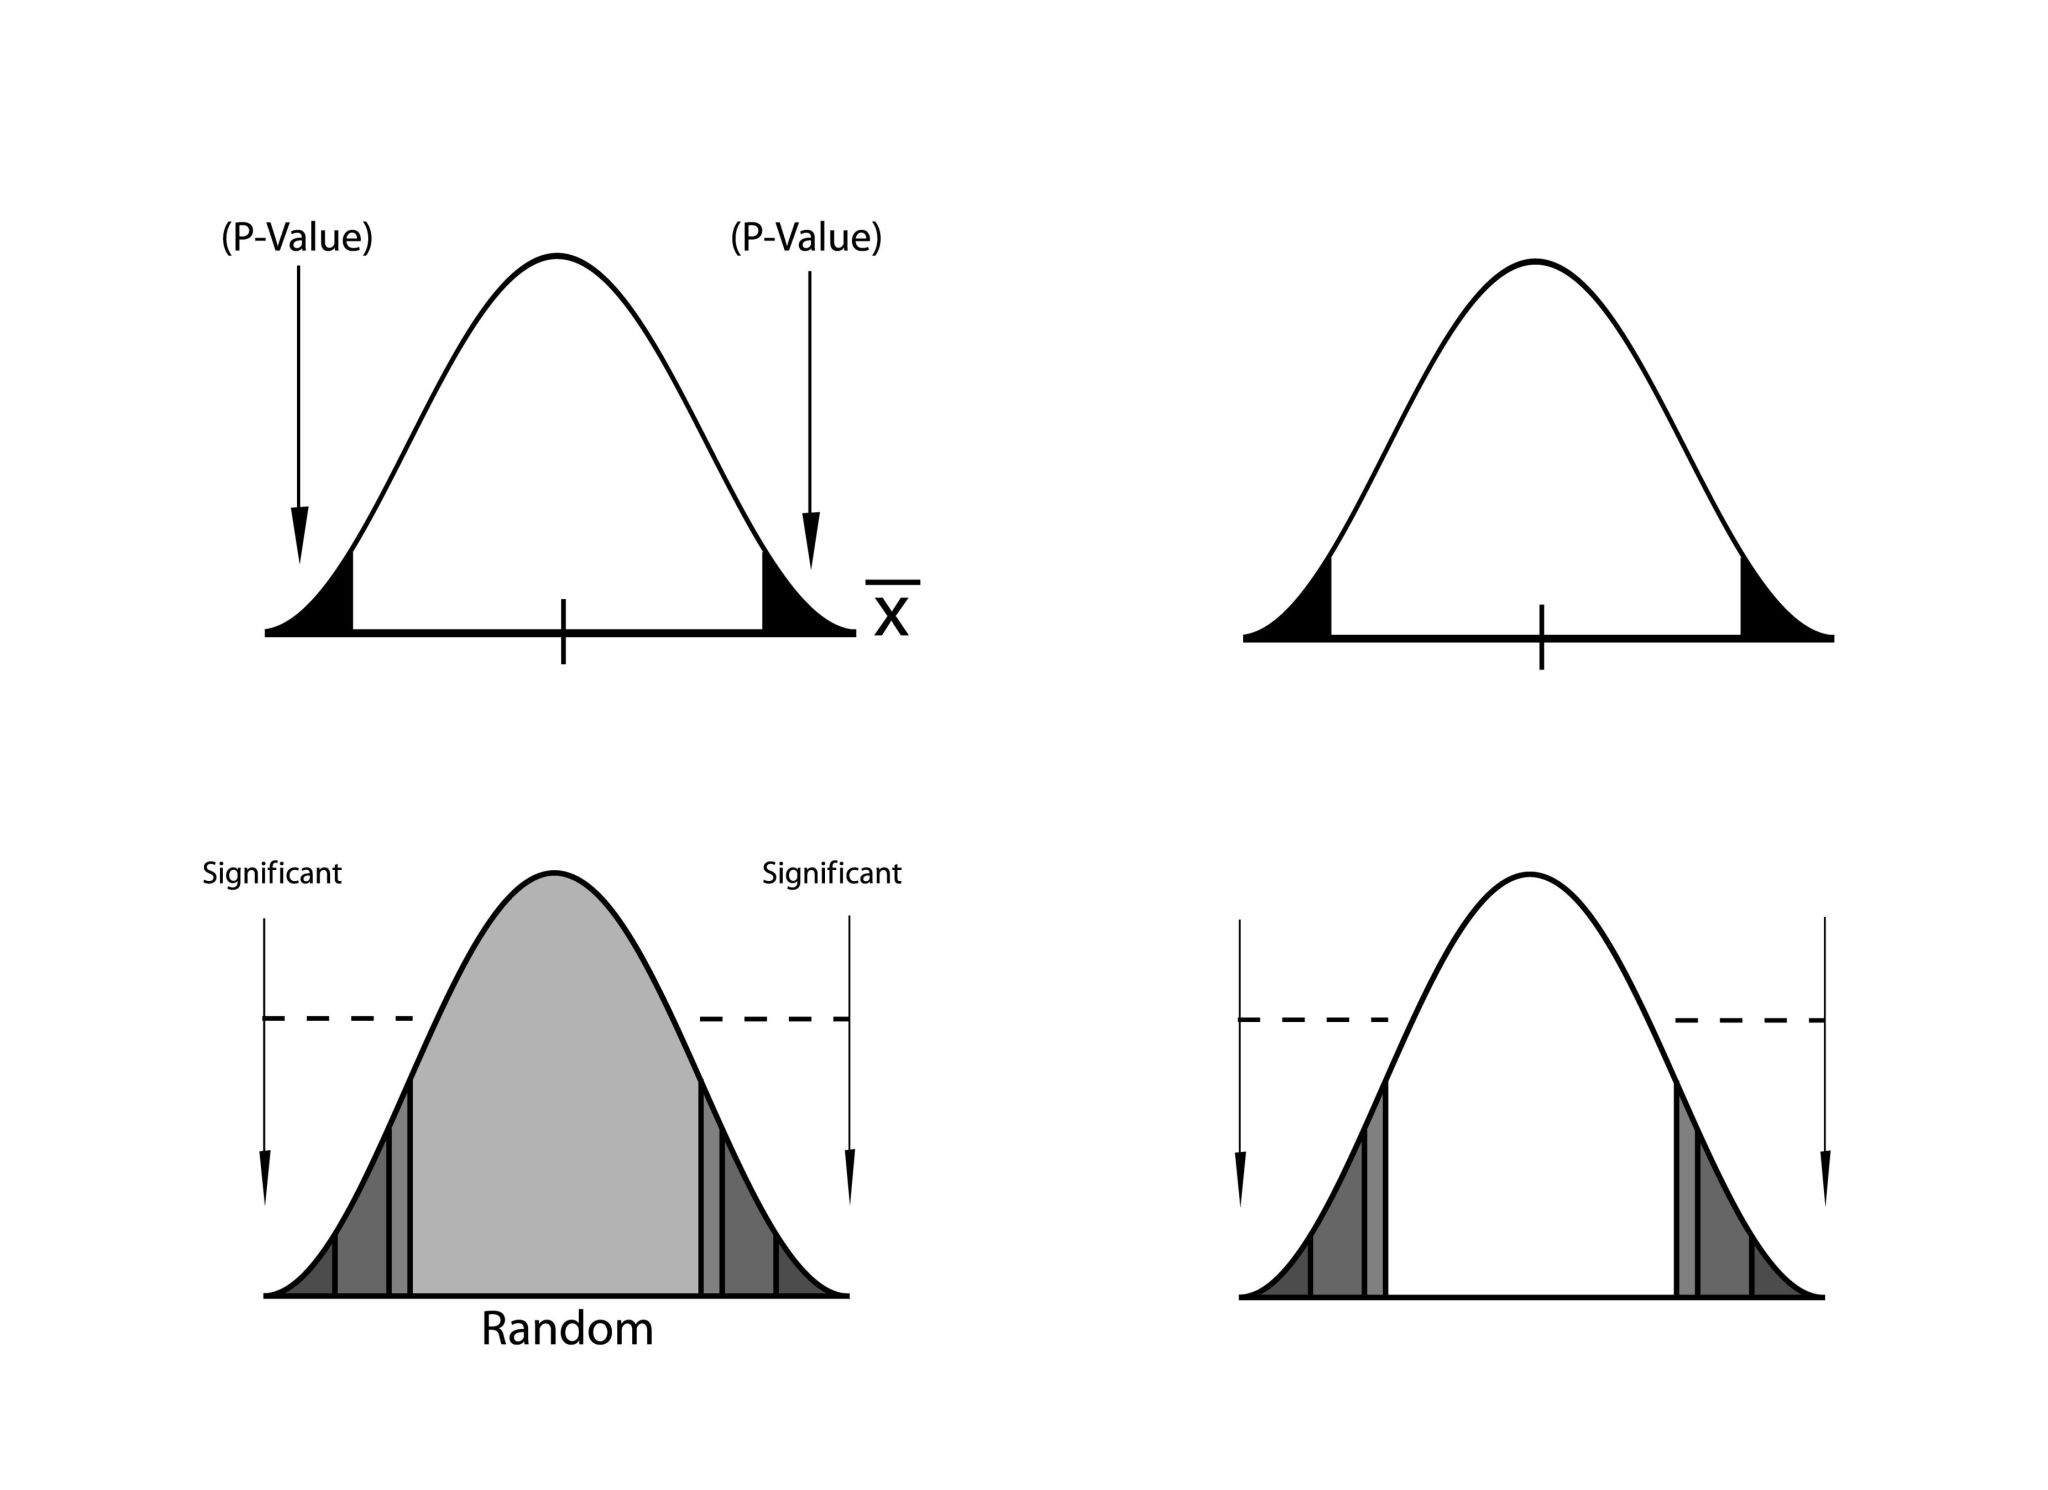

<center>Critical values define the boundaries of the tails. Source: Iamnee / Getty Images</center>

---

### How to Find the Critical Value (Z*)

Because a Confidence Interval estimates a parameter in *both* directions (above and below the mean), you are carving out the exact middle section of the curve. This means the leftover uncertainty ($\alpha$) is split perfectly in half into the two extreme tails.

**The Math for a 95% Confidence Interval:**

1. **Determine your Confidence Level ($C$):** $0.95$
2. **Determine your Alpha ($\alpha$):** $1 - 0.95 = 0.05$ (or 5% total error)
3. **Split Alpha in half ($\alpha/2$):** $0.05 / 2 = 0.025$ (2.5% in the left tail, 2.5% in the right tail).
4. **Find the Z-score:** You look up the point on the Standard Normal Distribution that leaves exactly 2.5% in the upper tail. That number is mathematically fixed at **1.96**.

Your critical value ($Z^*$) is $1.96$.

### Standard Critical Values Cheat Sheet

While you can calculate these using software or a Z-table, data scientists memorize these three values because they are universally standard across almost all statistical software:

| Confidence Level ($C$) | Total Alpha ($\alpha$) | Alpha Per Tail ($\alpha/2$) | Critical Value ($Z^*$) |
| --- | --- | --- | --- |
| **90%** | $0.10$ | $0.05$ | **1.645** |
| **95%** | $0.05$ | $0.025$ | **1.960** |
| **99%** | $0.01$ | $0.005$ | **2.576** |

### The Critical Value in Action: The Formula

The critical value is the engine inside the Confidence Interval formula. It acts as a strict multiplier against your Standard Error.

$$\text{Confidence Interval} = \bar{x} \pm (Z^* \times \text{Standard Error})$$

If you increase your Confidence Level from 90% to 99%, your critical multiplier jumps from $1.645$ to $2.576$. Because you are multiplying your error by a much larger number, your final interval becomes much wider.

Here is the complete Python code to build the interactive **Critical Value Visualizer** directly in a Google Colab notebook.

To provide practical sample data, this visualization is grounded in a machine learning context: **estimating the true mean accuracy of an ensemble model** based on several cross-validation runs.

* **Sample Mean ($\bar{x}$):** 88.5% accuracy
* **Standard Error:** 1.2%

As the confidence level is adjusted, the engine calculates the exact Critical Value ($Z^*$), draws the strict mathematical boundaries on the standard normal curve, and applies that multiplier to the sample data to generate the final Confidence Interval.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import ipywidgets as widgets
from IPython.display import display

# ==========================================
# 1. Define the Sample Data Context
# ==========================================
# Scenario: Estimating mean accuracy of an Ensemble Model
sample_mean = 88.5    # Mean accuracy of 88.5%
standard_error = 1.2  # Standard error of 1.2%

# ==========================================
# 2. Define the Visualization Engine
# ==========================================
def plot_critical_values(conf_level):
    plt.figure(figsize=(12, 6))

    # 1. Calculate the math based on the chosen confidence level
    alpha = 1 - (conf_level / 100)
    alpha_per_tail = alpha / 2

    # Find the Critical Z-Score (Z*)
    z_crit = norm.ppf(1 - alpha_per_tail)

    # Calculate the real-world interval using the Ensemble Model data
    margin_of_error = z_crit * standard_error
    lower_bound = sample_mean - margin_of_error
    upper_bound = sample_mean + margin_of_error

    # 2. Generate the Standard Normal Distribution Curve (Z-Distribution)
    x = np.linspace(-4, 4, 1000)
    y = norm.pdf(x, 0, 1)
    plt.plot(x, y, color='black', linewidth=2)

    # 3. Shade the Confidence Region (Middle)
    x_middle = np.linspace(-z_crit, z_crit, 500)
    y_middle = norm.pdf(x_middle, 0, 1)
    plt.fill_between(x_middle, y_middle, color='mediumseagreen', alpha=0.3,
                     label=f'Confidence Region ({conf_level}%)')

    # 4. Shade the Rejection Regions / Extreme Tails (Alpha/2)
    x_left_tail = np.linspace(-4, -z_crit, 200)
    y_left_tail = norm.pdf(x_left_tail, 0, 1)
    plt.fill_between(x_left_tail, y_left_tail, color='crimson', alpha=0.5,
                     label=f'Error Tails (\u03B1 = {alpha*100:.1f}%)')

    x_right_tail = np.linspace(z_crit, 4, 200)
    y_right_tail = norm.pdf(x_right_tail, 0, 1)
    plt.fill_between(x_right_tail, y_right_tail, color='crimson', alpha=0.5)

    # 5. Draw the Critical Value Boundaries
    plt.axvline(-z_crit, color='darkred', linestyle='--', linewidth=2)
    plt.axvline(z_crit, color='darkred', linestyle='--', linewidth=2)

    # Label the Critical Values directly on the x-axis
    plt.text(-z_crit, -0.02, f'-Z* = -{z_crit:.3f}', color='darkred', ha='center', fontweight='bold')
    plt.text(z_crit, -0.02, f'+Z* = +{z_crit:.3f}', color='darkred', ha='center', fontweight='bold')

    # 6. Formatting the visual curve
    plt.title('Critical Values ($Z^*$) on the Standard Normal Distribution', fontsize=15, pad=15)
    plt.xlabel('Z-Scores', fontsize=12)
    plt.ylabel('Probability Density', fontsize=12)
    plt.axhline(0, color='black', linewidth=1)
    plt.xlim(-4, 4)
    plt.ylim(-0.05, 0.45) # Lowered slightly to fit Z* labels
    plt.grid(axis='y', alpha=0.3)
    plt.legend(loc='upper right')

    # 7. Add dynamic text box showing the Sample Data Application
    application_text = (
        f"ENSEMBLE MODEL EVALUATION\n"
        f"Base Mean Accuracy: {sample_mean:.1f}% | Standard Error: {standard_error:.1f}%\n"
        f"Formula: {sample_mean:.1f} \u00B1 ({z_crit:.2f} * {standard_error:.1f})\n"
        f"Margin of Error: \u00B1 {margin_of_error:.2f}%\n"
        f"Final {conf_level}% CI: [{lower_bound:.2f}% , {upper_bound:.2f}%]"
    )
    plt.text(0, 0.15, application_text, fontsize=12, ha='center',
             bbox=dict(facecolor='white', edgecolor='mediumseagreen', alpha=0.9, boxstyle='round,pad=0.8'))

    plt.show()

# ==========================================
# 3. Create Interactive Controls
# ==========================================
# Create a slider to adjust the confidence level
confidence_slider = widgets.FloatSlider(
    value=95.0,
    min=80.0,
    max=99.9,
    step=0.1,
    description='Confidence Level (%):',
    continuous_update=True,
    layout=widgets.Layout(width='600px'),
    style={'description_width': 'initial'}
)

# Link the slider to the visualization function
interactive_critical_values = widgets.interactive(plot_critical_values, conf_level=confidence_slider)

# Display the interactive UI
display(interactive_critical_values)

interactive(children=(FloatSlider(value=95.0, description='Confidence Level (%):', layout=Layout(width='600px'…

### What to look for when you run it:

* **Watch the red tails (Alpha):** As you increase the Confidence Level toward 99%, notice how the green shaded area pushes outward, squeezing the red error tails ($\alpha$) into the extreme edges of the curve.
* **Track the Critical Value ($Z^*$):** Look at the bold red text on the x-axis. As certainty increases, the critical value acts as a boundary fence being pushed further away from zero.
* **See the math applied:** Inside the floating text box, watch how the changing $Z^*$ acts as a strict multiplier against the model's standard error, physically widening the final prediction interval for the ensemble model's accuracy.